In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, restoration, img_as_float, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os
import glob

In [29]:
# locate the blurred images
blurred_foler = "../data/blur/images/"
image_extensions = ["*.png", "*.jpg", "*.jpeg"]
image_paths = []


In [30]:
for e in image_extensions:
    image_paths.extend(glob.glob(os.path.join(blurred_foler, e)))

print(f"Found blurred images:{len(image_paths)}")

Found blurred images:1029


In [31]:
# define the blur kernesl (PSF))
# PSF: Point Spread Function.
# Kernel size: the size of the PSF kernel
# Sigma: to control the amount of blurring. A larger sigma will result in a blurrier image.
# using Gaussian kernel as the PSF for Wiener deblurring

kernel_size = 15 # assumption
sigma = 3 # assumption

def gaussian_kernel(size=15, power=3):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * power**2))
    return kernel / kernel.sum()

psf = gaussian_kernel(kernel_size, sigma)
print(f"PSD Shape: {psf.shape}")
print(f"PSF Sum: {psf.sum():.4f}") # 1
      


PSD Shape: (15, 15)
PSF Sum: 1.0000


In [32]:
# make wiener filter
def wiener_filter(blur_img, psf, wiener_balance = 0.15): 
    deblurred_channel = []
    for ch in range(3):
        restored_ch = restoration.wiener(blur_img[:,:,ch], psf, balance=wiener_balance)
        deblurred_channel.append(restored_ch)
    
    deblurred = np.stack(deblurred_channel, axis=-1)
    deblurred = np.clip(deblurred, 0, 1)

    return deblurred




In [ ]:
# implement PSD and wiener filter

kernel_size = 15 # assumption
sigma = 3 # assumption
wiener_balance = 0.15 # assumption

def deblur_wiener(blur_img, size=15, power=3, balance=0.15):
    # get the image
    blurred_raw = io.imread(blur_img) # to convert the image to a floating-point representation in the range [0, 1]
    blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)

    # call gaussian kernel
    psf = gaussian_kernel(size=size, power=power) # make gaussian kernel
    # call wiener filter
    result = wiener_filter(blurred, psf,wiener_balance=balance)
    
    return result # the result shape is 720x1280x3


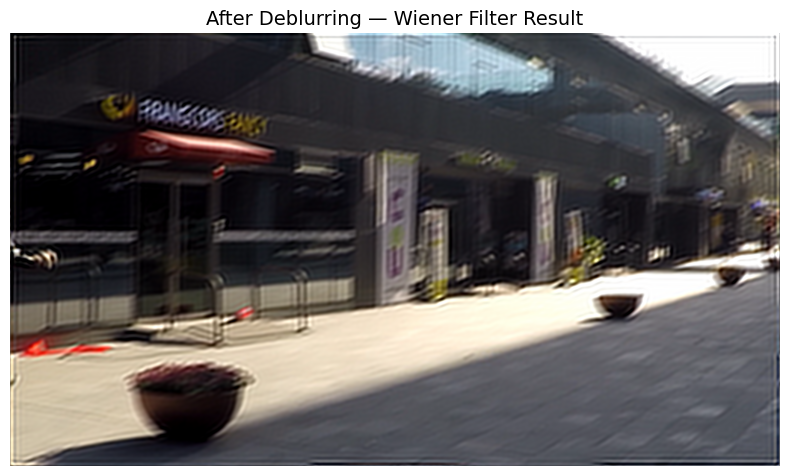

In [33]:
IMAGE_PATH = "../data/blur/images/000001.png"  # Update path if needed

result_deblur = deblur_wiener(IMAGE_PATH)

# ─────────────────────────────────────────────
# STEP 4: View the deblurred image
# ─────────────────────────────────────────────

plt.figure(figsize=(8, 5))
plt.imshow(result_deblur)
plt.title("After Deblurring — Wiener Filter Result", fontsize=14)
plt.axis("off")
plt.tight_layout()
# plt.savefig("after_deblur.png", dpi=150)
plt.show()
# print("✔ Saved: after_deblur.png\n")

In [28]:
result_deblur.shape

(720, 1280, 3)

In [ ]:
IMAGE_PATH = "D:/MSC AIML - Adelaide/!-COURSES-!/7- COMPUTER VISION AND MULTIMODAL ML/Assignment/Assignment 1/data/blur/images/000001.png"  # Update path if needed

blurred_raw = io.imread(IMAGE_PATH) # to convert the image to a floating-point representation in the range [0, 1]
blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)

In [12]:
for i in range(3):
    print(image_paths[i])
    blurred_raw = io.imread(image_paths[i])
    blurred = img_as_float(blurred_raw)
    print(f"Shape of the image: {blurred.shape}")

    # 

D:/MSC AIML - Adelaide/!-COURSES-!/7- COMPUTER VISION AND MULTIMODAL ML/Assignment/Assignment 1/data/blur/images\000001.png
Shape of the image: (720, 1280, 3)
D:/MSC AIML - Adelaide/!-COURSES-!/7- COMPUTER VISION AND MULTIMODAL ML/Assignment/Assignment 1/data/blur/images\000002.png
Shape of the image: (720, 1280, 3)
D:/MSC AIML - Adelaide/!-COURSES-!/7- COMPUTER VISION AND MULTIMODAL ML/Assignment/Assignment 1/data/blur/images\000003.png
Shape of the image: (720, 1280, 3)


### Function to implement wiener filter to all blur image

In [ ]:
BLUR_PATH = "../data/sharp/images/"
image_extensions = ["*.png", "*.jpg", "*.jpeg"]

def implement_wiener(path):
    blur_paths = []

    # get the blur images path
    for e in image_extensions:
        blur_paths.extend(glob.glob(os.path.join(path, e)))
    print(f"Found blur images:{len(blur_paths)}")

    result_deblur_list = []
    for i in blur_paths:
        result_deblur = deblur_wiener(i) # implement deblur_wiener function
        result_deblur_list.append(result_deblur)
    
    return result_deblur_list

deblur_float_list = implement_wiener(BLUR_PATH) # 7 min 50 secs


Found blur images:1029


### Functions to convert sharp images to

In [ ]:
SHARP_PATH = "../data/sharp/images/"

def get_sharp_images(path):
    """
    add definition here
    """
    sharp_paths = []
    result_sharp = []

    for e in image_extensions:
        sharp_paths.extend(glob.glob(os.path.join(path, e)))
    
    print(f"Found sharp images:{len(sharp_paths)}")

    for i in sharp_paths:
        sharp_raw = io.imread(i) # to convert the image to a floating-point representation in the range [0, 1]
        sharp_float = img_as_float(sharp_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)
        result_sharp.append(sharp_float)
    
    return result_sharp

sharp_float_list = get_sharp_images(SHARP_PATH) # 1 min 30 secs


Found sharp images:1029


In [54]:
print(len(deblur_float_list))
print(len(sharp_float_list))

1029
1029


In [57]:
psnr_val = psnr(deblur_float_list[1], sharp_float_list[1], data_range=1.0)
print(f"  PSNR  : {psnr_val:.2f} dB")

ssim_val = ssim(deblur_float_list[1], sharp_float_list[1], channel_axis=2, data_range=1.0)
print(f"  SSIM  : {ssim_val:.4f}")



  PSNR  : 23.57 dB
  SSIM  : 0.7441


In [ ]:
# make function to call wiener, compare to sharp images, and produce result in list format

'../data/sharp/images\\000001.png'

In [ ]:
# change